In [ ]:
import pandas as pd          # DataFrames — think of it as Python's Excel
import numpy  as np          # Fast numeric arrays & math operations

# ── Visualisation ──────────────────────────────────────────
import matplotlib.pyplot as plt  # Core plotting library
import seaborn           as sns  # Higher-level plots built on matplotlib

# ── Scikit-learn: ML toolkit ────────────────────────────────
from sklearn.model_selection import train_test_split      # Split data into train/test
from sklearn.ensemble        import RandomForestClassifier # Our main model
from sklearn.preprocessing   import LabelEncoder           # Encodes target column (yes/no → 1/0)
from sklearn.metrics         import (
    accuracy_score,           # % of correct predictions
    classification_report,    # precision, recall, F1 per class
    confusion_matrix,         # TP / TN / FP / FN breakdown
    ConfusionMatrixDisplay,   # Plots the confusion matrix nicely
)

print("✅ All libraries loaded!")


✅ All libraries loaded!


In [ ]:
# Read the CSV file — creates a DataFrame (rows × columns table)
df = pd.read_csv("bank.csv")

# Quick sanity checks
print(f"\n📊 Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())     # Shows the first 5 rows — always do this first!


📊 Dataset shape: 11162 rows × 17 columns

First 5 rows:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  



📋 Column info:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

🔍 Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

🎯 Target distribution:
deposit
no     5873
yes    5289
Name: count, dtype: int64
deposit
no     52.6%
yes    47.4%
Name: proportion, dtype: object

📈 Numeric column statistics:
                age       balance           day      duration      campaign  \
count  11162.000000  11162.000000  11162.000000  11162.000000  11162.000000

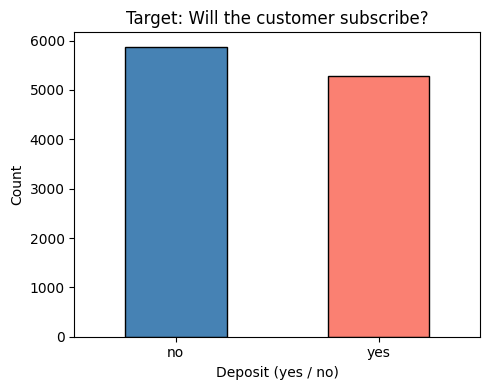

In [ ]:
# ── 2a. Column names & data types ──────────────────────────
# Tells you which columns are text (object) vs numeric (int/float)
print("\n📋 Column info:")
print(df.dtypes)

# ── 2b. Missing value check ─────────────────────────────────
# Any column with nulls needs to be handled before training
print("\n🔍 Missing values per column:")
print(df.isnull().sum())     # 0 means no missing — the bank dataset is clean

# ── 2c. Target class balance ────────────────────────────────
# Check if "yes" and "no" are roughly equal — imbalance affects the model
print("\n🎯 Target distribution:")
print(df["deposit"].value_counts())
print(df["deposit"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")

# ── 2d. Numeric statistics ──────────────────────────────────
# Min, max, mean, std dev — good for spotting outliers
print("\n📈 Numeric column statistics:")
print(df.describe())

# ── 2e. Bar chart of target distribution ───────────────────
plt.figure(figsize=(5, 4))
df["deposit"].value_counts().plot(kind="bar", color=["steelblue", "salmon"], edgecolor="black")
plt.title("Target: Will the customer subscribe?")
plt.xlabel("Deposit (yes / no)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# ── 3a. Separate features (X) and target (y) ───────────────
# X = everything the model uses as inputs
# y = the column we want to predict
X = df.drop(columns=["deposit"])   # All columns except the target
y = df["deposit"]                  # The label column: "yes" / "no"

print(f"\n✂️  Features shape (before encoding): {X.shape}")
print(f"   Target shape                     : {y.shape}")

# ── 3b. Find all text (object) columns ─────────────────────
# ML models need numbers — text must be converted first
text_columns = X.select_dtypes(include="object").columns.tolist()
print(f"\n🔤 Text columns to One-Hot Encode: {text_columns}")

# ── 3c. One-Hot Encode all text columns ────────────────────
# get_dummies creates a binary (0/1) column for each unique category value.
# drop_first=True removes one column per feature to avoid the "dummy trap":
#   e.g. if "not married" AND "not single" are both 0, we already know "divorced"
#   keeping all columns creates redundant info that confuses some algorithms.
X_encoded = pd.get_dummies(X, columns=text_columns, drop_first=True)

print(f"\n✅ Features shape (after encoding): {X_encoded.shape}")
print(f"   New columns added: {X_encoded.shape[1] - X.shape[1]}")
print("\nFirst 3 rows (showing new binary columns):")
print(X_encoded.head(3))

# ── 3d. Encode the target column ────────────────────────────
# LabelEncoder converts: "yes" → 1,  "no" → 0
# We use this (not get_dummies) because it's a binary label, not a feature.
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"\nTarget sample: {y[:5].tolist()}  →  {y_encoded[:5].tolist()}")


✂️  Features shape (before encoding): (11162, 16)
   Target shape                     : (11162,)

🔤 Text columns to One-Hot Encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

✅ Features shape (after encoding): (11162, 42)
   New columns added: 26

First 3 rows (showing new binary columns):
   age  balance  day  duration  campaign  pdays  previous  job_blue-collar  \
0   59     2343    5      1042         1     -1         0            False   
1   56       45    5      1467         1     -1         0            False   
2   41     1270    5      1389         1     -1         0            False   

   job_entrepreneur  job_housemaid  ...  month_jul  month_jun  month_mar  \
0             False          False  ...      False      False      False   
1             False          False  ...      False      False      False   
2             False          False  ...      False      False      False   

   month_may  month_nov  month_oct  mo

In [ ]:
# Split the data: 80% for training, 20% for testing.
# The model learns ONLY from X_train / y_train.
# X_test / y_test act as the "final exam" — unseen data.
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,          # features (now all numeric after OHE)
    y_encoded,          # target (0 or 1)
    test_size=0.2,      # 20% goes to testing
    random_state=42,    # fixes randomness → same split every run
    stratify=y_encoded, # keeps yes/no ratio equal in both splits
)

print(f"\n📦 Training samples : {X_train.shape[0]}")
print(f"   Testing samples  : {X_test.shape[0]}")
print(f"   Total features   : {X_train.shape[1]}")


📦 Training samples : 8929
   Testing samples  : 2233
   Total features   : 42


In [ ]:
# Random Forest = an ensemble of many Decision Trees.
# Each tree sees a random subset of data and features.
# Final prediction = majority vote across all trees.

model = RandomForestClassifier(
    n_estimators=300,       # number of trees — more = stable but slower
    min_samples_split=10,   # a node needs ≥10 samples before it can split
    min_samples_leaf=2,     # each leaf must have ≥2 samples — reduces overfitting
    max_features=0.5,       # each split considers 50% of features randomly
    max_depth=20,           # trees grow up to 20 levels deep
    bootstrap=True,         # each tree trains on a random sample-with-replacement
    random_state=42,        # reproducibility
)

print("\n⏳ Training the Random Forest...")
model.fit(X_train, y_train)   # ← This is where ALL learning happens!
print("✅ Model trained!")


⏳ Training the Random Forest...
✅ Model trained!


In [ ]:
# model.predict() passes each test row through all 300 trees,
# takes the majority vote, and returns 0 (no) or 1 (yes).
y_pred = model.predict(X_test)

# Quick eyeball: compare first 10 predictions vs actual labels
print("\n🔮 First 10 predictions vs actual:")
print(f"   Predicted : {y_pred[:10]}")
print(f"   Actual    : {y_test[:10]}")
print("   (1 = subscribed yes, 0 = no)")


🔮 First 10 predictions vs actual:
   Predicted : [1 1 1 0 1 0 0 0 1 1]
   Actual    : [0 1 0 0 1 0 0 1 1 1]
   (1 = subscribed yes, 0 = no)



🎯 Accuracy: 86.07%

📝 Classification Report:
              precision    recall  f1-score   support

      No (0)       0.89      0.83      0.86      1175
     Yes (1)       0.83      0.89      0.86      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233



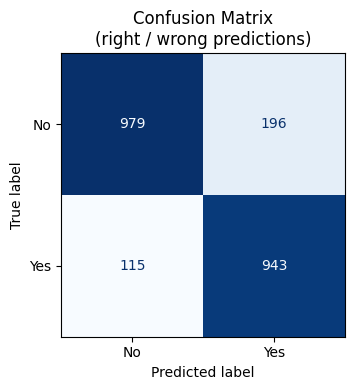

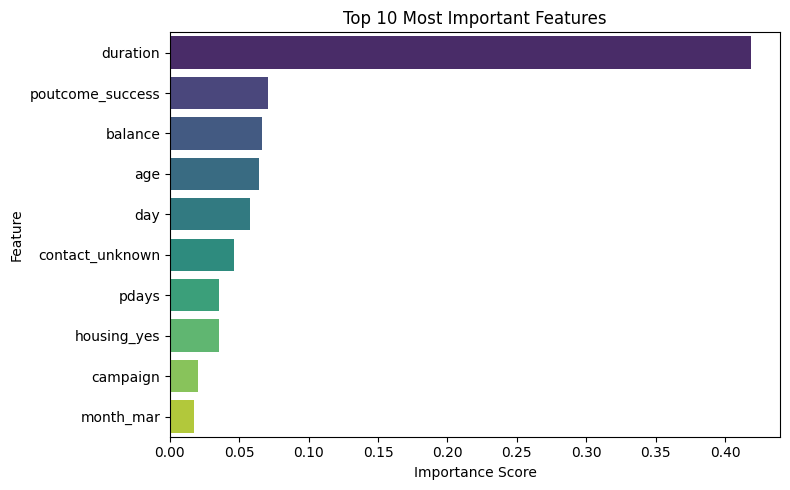

In [ ]:
# ── 7a. Accuracy ────────────────────────────────────────────
# Simple % of predictions that were correct.
# ⚠️ Can be misleading for imbalanced datasets!
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Accuracy: {accuracy * 100:.2f}%")

# ── 7b. Classification Report ───────────────────────────────
# Precision = of all predicted "yes", how many were truly "yes"?
# Recall    = of all actual "yes", how many did we correctly catch?
# F1-score  = harmonic mean of Precision & Recall (best single metric)
print("\n📝 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No (0)", "Yes (1)"]))

# ── 7c. Confusion Matrix ────────────────────────────────────
# Grid showing where predictions were right and where they went wrong:
#              Predicted No    Predicted Yes
# Actual No  [ True Negative ] [ False Positive ]  ← correctly said "no" / wrongly said "yes"
# Actual Yes [ False Negative] [ True Positive  ]  ← missed a "yes"     / correctly said "yes"
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix\n(right / wrong predictions)")
plt.tight_layout()
plt.show()

# ── 7d. Feature Importance ──────────────────────────────────
# Which features did the model rely on most?
# Note: One-Hot Encoding splits one column into many,
# spreading importance across them (e.g. "job_admin", "job_blue-collar"…)
importances  = model.feature_importances_
feature_names = X_encoded.columns

feat_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values("Importance", ascending=False)
    .head(10)
)
plt.figure(figsize=(8, 5))
sns.barplot(data=feat_df, x="Importance", y="Feature", palette="viridis")
plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "=" * 55)
print("       🎉 DONE! Here's a quick summary:")
print("=" * 55)
print(f"  Dataset size        : {df.shape[0]} customers")
print(f"  Original features   : {X.shape[1]}")
print(f"  Features after OHE  : {X_encoded.shape[1]}")   # OHE adds many new columns
print(f"  Train size          : {X_train.shape[0]}")
print(f"  Test size           : {X_test.shape[0]}")
print(f"  Accuracy            : {accuracy * 100:.2f}%")
print("=" * 55)


       🎉 DONE! Here's a quick summary:
  Dataset size        : 11162 customers
  Original features   : 16
  Features after OHE  : 42
  Train size          : 8929
  Test size           : 2233
  Accuracy            : 86.07%
